In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

Figure dispersion relation

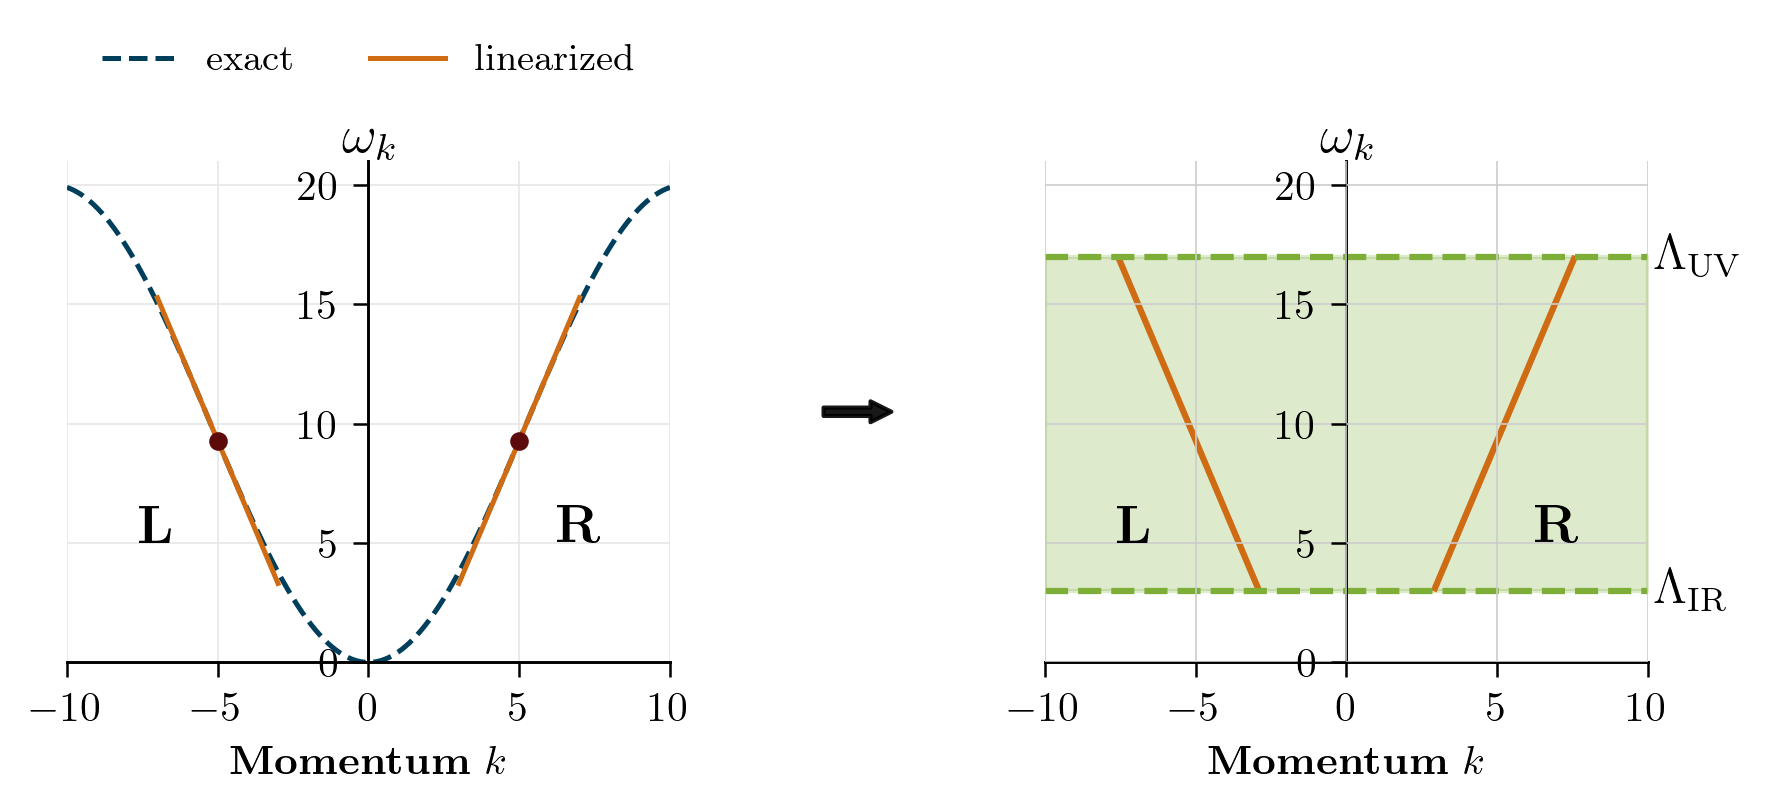

In [13]:
color_omega_exact = "#003f5c"
color_omega_lin = "#cf6c13"
color_truncation = "#7dae37"

# -------------------------
# Physical parameters
# -------------------------

J = 5
a = 0.3
k0 = 5

k_tab = np.linspace(-10, 10, 1000)

omega_exact = -2*J*np.cos(a*k_tab) + 2*J

omega0 = -2*J*np.cos(a*k0) + 2*J
vg = 2*J*a*np.sin(a*k0)

k_lin_R = np.linspace(k0-2, k0+2, 200)
omega_lin_R = omega0 + vg*(k_lin_R - k0)

k_lin_L = np.linspace(-k0-2, -k0+2, 200)
omega_lin_L = omega0 - vg*(k_lin_L + k0)

# -------------------------
# Cutoffs
# -------------------------

Lambda_IR = 3
Lambda_UV = 17

# -------------------------
# FIGURE
# -------------------------

fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(6,3),
    dpi=300,
    gridspec_kw={"width_ratios":[1,0.35,1]}
)

# =====================================================
# LEFT PANEL
# =====================================================

ax1.scatter([k0], [omega0], color='#5c0a0a', s=12, zorder=3)
ax1.scatter([-k0], [omega0], color='#5c0a0a', s=12, zorder=3)

ax1.plot(
    k_tab,
    omega_exact,
    lw=1.2,
    linestyle="--",
    color=color_omega_exact,
    label="exact"
)

ax1.plot(
    k_lin_R,
    omega_lin_R,
    lw=1.2,
    color=color_omega_lin,
    label="linearized"
)

ax1.plot(
    k_lin_L,
    omega_lin_L,
    lw=1.2,
    color=color_omega_lin
)
ax1.set_xlabel(r'\textbf{Momentum} $k$')
ax1.set_xlim(-10,10)
ax1.set_ylim(0,21)

ax1.spines['left'].set_position('center')
ax1.spines['right'].set_color('none')
ax1.spines['top'].set_color('none')

ax1.grid(color='0.9', linewidth=0.4)

# ω label
ax1.text(
    0,
    ax1.get_ylim()[1]*1.02,
    r'$\omega_k$',
    ha='center',
    size=13
)

# L label
ax1.text(
    -7,
    5,
    r'\textbf{L}',
    ha='center',
    size=13
)

# R label
ax1.text(
    7,
    5,
    r'\textbf{R}',
    ha='center',
    size=13
)


#Legend

ax1.legend(
    frameon=False,
    fontsize=9,
    loc="upper center",
    ncols=2,
    bbox_to_anchor=(0.5, 1.3)
)

# =====================================================
# MIDDLE PANEL = ONLY ARROW
# =====================================================

ax2.axis("off")

ax2.annotate(
    "",
    xy=(0.7,0.5),
    xytext=(0.3,0.5),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="simple",
        color="black",
        alpha=0.9
    )
)

# =====================================================
# RIGHT PANEL
# =====================================================

k_lin = np.linspace(-10,10,400)

omega_R = omega0 + vg*(k_lin - k0)
omega_L = omega0 - vg*(k_lin + k0)

mask_R = (omega_R < Lambda_UV) & (omega_R > Lambda_IR)
mask_L = (omega_L < Lambda_UV) & (omega_L > Lambda_IR)

ax3.plot(k_lin[mask_R], omega_R[mask_R], color=color_omega_lin, lw=1.5)
ax3.plot(k_lin[mask_L], omega_L[mask_L], color=color_omega_lin, lw=1.5)

ax3.axhline(Lambda_IR, linestyle='--', color=color_truncation)
ax3.axhline(Lambda_UV, linestyle='--', color=color_truncation)

#Indicate lambda_IR and lambda_UV on the plot with text 
ax3.text(10.2, Lambda_IR, r'$\Lambda_{\mathrm{IR}}$', va='center', fontsize=12, color='black') 
ax3.text(10.2, Lambda_UV, r'$\Lambda_{\mathrm{UV}}$', va='center', fontsize=12, color='black')

ax3.fill_between(
    k_lin,
    Lambda_IR,
    Lambda_UV,
    color=color_truncation,
    alpha=0.25,
    zorder=-1
)


ax3.set_xlabel(r'\textbf{Momentum} $k$')
ax3.set_xlim(-10,10)
ax3.set_ylim(0,21)

ax3.spines['left'].set_position('center')
ax3.spines['right'].set_color('none')
ax3.spines['top'].set_color('none')

# ω label
ax3.text(
    0,
    ax1.get_ylim()[1]*1.02,
    r'$\omega_k$',
    ha='center',
    size=13
)

# L label
ax3.text(
    -7,
    5,
    r'\textbf{L}',
    ha='center',
    size=13
)

# R label
ax3.text(
    7,
    5,
    r'\textbf{R}',
    ha='center',
    size=13
)

ax3.set_axisbelow(False)
ax3.grid(color='0.8', linewidth=0.4)

plt.tight_layout()
plt.savefig( 
    "../results/fig/dispersion_relation.pdf",
    bbox_inches="tight",
    pad_inches=0.2
)
plt.show()